## Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set(style="whitegrid")

## Load Dataset

In [2]:
df = pd.read_csv('demand_forecasting.csv')  # upload file in Colab

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store ID', 'Product ID', 'Date'])

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
100,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
200,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
300,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
400,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110


## Feature Engineering

In [3]:
def create_features(df):
    df = df.copy()

    # Time features
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek

    # Pricing
    df['PriceDiff'] = df['Competitor Pricing'] - df['Price']

    # Lag features
    df['Lag7'] = df.groupby(['Store ID','Product ID'])['Demand'].shift(7)
    df['Lag14'] = df.groupby(['Store ID','Product ID'])['Demand'].shift(14)

    return df

df = create_features(df)
df = df.dropna()

## Encode Categorical Data

In [ ]:
cat_cols = ['Category','Region','Weather Condition','Seasonality','Store ID','Product ID']

category_options = {
    col: sorted(df[col].dropna().astype(str).unique().tolist())
    for col in cat_cols
}

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le


## Train-Test Split (Time-Based)

In [ ]:
split_date = df['Date'].quantile(0.8)

train = df[df['Date'] <= split_date]
test = df[df['Date'] > split_date]

X_train = train.drop(['Demand','Date'], axis=1)
y_train = train['Demand']

X_test = test.drop(['Demand','Date'], axis=1)
y_test = test['Demand']

X_train_values = X_train.to_numpy(dtype=np.float32, copy=True)
y_train_values = y_train.to_numpy(dtype=np.float32, copy=True)
X_test_values = X_test.to_numpy(dtype=np.float32, copy=True)
y_test_values = y_test.to_numpy(dtype=np.float32, copy=True)


## Train Models

In [ ]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=42,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1,
    ),
}

results = []

for name, model in models.items():
    model.fit(X_train_values, y_train_values)
    preds = model.predict(X_test_values)

    mae = mean_absolute_error(y_test_values, preds)
    rmse = np.sqrt(mean_squared_error(y_test_values, preds))
    r2 = r2_score(y_test_values, preds)

    results.append([name, mae, rmse, r2])
    print(f"{name} -> MAE:{mae:.2f}, RMSE:{rmse:.2f}, R2:{r2:.3f}")


## Compare Models

In [13]:
results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,LightGBM,11.492263,14.887909,0.886468
1,XGBoost,11.442173,14.896652,0.886335
0,RandomForest,12.388758,16.184508,0.865832


## Visualization

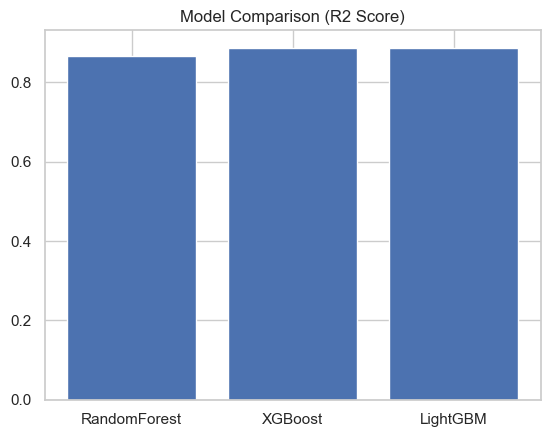

In [14]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison (R2 Score)")
plt.show()

## Prediction Example

In [16]:
best_model_name = results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

prediction = best_model.predict(X_test[:1])

print(f"Best model: {best_model_name}")
print("Next Demand Prediction:", prediction[0])


Best model: LightGBM
Next Demand Prediction: 122.98971112491165


In [19]:
import pickle

# Create category options (only if needed)
category_options = {
    col: X_train[col].unique().tolist()
    for col in X_train.select_dtypes(include='object').columns
}

bundle = {
    "model": best_model,
    "columns": X_train.columns.tolist(),
    "encoders": encoders,
    "category_options": category_options
}

with open("demand_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("Model saved as demand_model.pkl")

Model saved as demand_model.pkl
